# JPX Tokyo Stock Exchange Prediction — 대회 소개 & 베이스라인 재현

Kaggle의 **JPX Tokyo Market Prediction** 대회 데이터를 우리 프로젝트 스타일로 정리한 노트북입니다.
원본(`code/jpx/easy-to-understand-the-competition.ipynb`, 135 cells)에서 핵심만 뽑아와 `src/jpx_loader.py`와 `src/jpx_metric.py`의 헬퍼로 대체했습니다.

## 구성
1. 데이터 로드 (`src.jpx_loader`)
2. Target 정의 복습 — `(Close_{t+2} - Close_{t+1}) / Close_{t+1}`
3. Rank 컬럼 만들기
4. 하루치 Spread Return (`Sup - Sdown`)
5. 기간 전체 Sharpe 점수 (대회 공식 메트릭)
6. 보조 파일들 훑어보기 (`trades`, `secondary_stock_prices`, `financials`, `options`, `stock_list`)

## 대회 개요
- 매일 2000여 종목에 대해 `Rank`(0~N-1, 내림차순)를 예측
- 상위 200개 매수 / 하위 200개 공매도, `linspace(2, 1, 200)` 가중치
- 최종 점수 = 기간 전체 일별 스프레드 수익의 **Sharpe ratio**

## 0. 환경 세팅

In [1]:
import sys
from pathlib import Path

# notebooks/ 에서 한 단계 위(프로젝트 루트)를 sys.path에 추가 → `from src import ...` 가능하게.
ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import jpx_loader, jpx_metric

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.2.3
numpy: 2.2.6


## 1. 데이터 로드

Kaggle train split(`train_files/stock_prices.csv`) — 2017~2021년 일봉.


In [2]:
prices = jpx_loader.load_stock_prices("train")
print("shape:", prices.shape)
print("기간:", prices["Date"].min(), "~", prices["Date"].max())
print("종목 수:", prices["SecuritiesCode"].nunique())
prices.head(3)

shape: (2332531, 12)
기간: 2017-01-04 00:00:00 ~ 2021-12-03 00:00:00
종목 수: 2000


,RowId,Date,SecuritiesCode,Open,High,Low,Close,Volume,AdjustmentFactor,ExpectedDividend,SupervisionFlag,Target
0,20170104_1301,2017-01-04,1301,2734.0,2755.0,2730.0,2742.0,31400,1.0,NaN,False,0.000730
1,20170104_1332,2017-01-04,1332,568.0,576.0,563.0,571.0,2798500,1.0,NaN,False,0.012324
2,20170104_1333,2017-01-04,1333,3150.0,3210.0,3140.0,3210.0,270800,1.0,NaN,False,0.006154


In [3]:
# dtype과 결측 현황.
print(prices.dtypes)
print("\n결측치:")
print(prices.isna().sum())

RowId                       object
Date                datetime64[ns]
SecuritiesCode               int64
Open                       float64
High                       float64
Low                        float64
Close                      float64
Volume                       int64
AdjustmentFactor           float64
ExpectedDividend           float64
SupervisionFlag               bool
Target                     float64
dtype: object

결측치:
RowId                     0
Date                      0
SecuritiesCode            0
Open                   7608
High                   7608
Low                    7608
Close                  7608
Volume                    0
AdjustmentFactor          0
ExpectedDividend    2313666
SupervisionFlag           0
Target                  238
dtype: int64


## 2. Target 재현

`src.jpx_metric.compute_target_from_close`가 공식 정의를 그대로 구현합니다.
`stock_prices.csv`에 이미 `Target`이 있어서 '검증용'으로만 사용합니다.

In [4]:
code = 1301  # 임의 종목
series = jpx_loader.get_stock_series(prices, code)
recomputed = jpx_metric.compute_target_from_close(series["Close"])

cmp = pd.DataFrame({"원본_Target": series["Target"], "재계산": recomputed})
cmp.dropna().head(10)

,원본_Target,재계산
Date,,
2017-01-04,0.000730,0.000730
2017-01-05,0.002920,0.002920
2017-01-06,-0.001092,-0.001092
2017-01-10,-0.005100,-0.005100
2017-01-11,-0.003295,-0.003295
2017-01-12,-0.006613,-0.006613
2017-01-13,-0.006657,-0.006657
2017-01-16,0.002978,0.002978
2017-01-17,0.001856,0.001856


In [5]:
# 두 값의 최대 오차. 부동소수 오차 수준이어야 정상.
diff = (cmp["원본_Target"] - cmp["재계산"]).abs().dropna()
print("max abs diff:", diff.max())

max abs diff: 2.0209528495129803e-16


## 3. Rank 컬럼 만들기

대회 제출물은 `(Date, SecuritiesCode, Rank)`. 일자별로 `Target` 내림차순 → 0-index Rank.
여기서는 **실제 Target을 컨닝**해서 '완벽한 Rank'를 만들고 대회 메트릭의 상한을 확인해봅니다.

In [6]:
# 2021년 이후 데이터만 추려서 분석 비용을 낮춥니다 (샘플 크기는 여전히 대회 규모).
sub = prices[prices["Date"] >= "2021-01-01"].dropna(subset=["Target"]).copy()
sub = jpx_loader.add_rank_column(sub, target_col="Target")
print("shape:", sub.shape)
sub[["Date", "SecuritiesCode", "Close", "Target", "Rank"]].head(6)

shape: (452000, 13)


,Date,SecuritiesCode,Close,Target,Rank
1880531,2021-01-04,1301,2950.0,0.011502,655.0
1880532,2021-01-04,1332,421.0,0.019093,375.0
1880533,2021-01-04,1333,2202.0,0.015075,497.0
1880534,2021-01-04,1375,1674.0,-0.003503,1481.0
1880535,2021-01-04,1376,1588.0,-0.012033,1737.0
1880536,2021-01-04,1377,3560.0,0.015471,483.0


In [7]:
# 불변식 확인: 각 날짜의 Rank는 0부터 연속.
bounds = sub.groupby("Date")["Rank"].agg(["min", "max", "count"])
assert (bounds["min"] == 0).all()
assert (bounds["max"] == bounds["count"] - 1).all()
print("OK — 모든 날짜에서 Rank가 [0, n-1] 연속 정수.")

OK — 모든 날짜에서 Rank가 [0, n-1] 연속 정수.


## 4. 하루치 Spread Return

하루를 뽑아서 `Sup - Sdown`을 눈으로 확인합니다.

In [8]:
one_date = sub["Date"].iloc[0]
df_day = sub[sub["Date"] == one_date]
spread = jpx_metric.daily_spread_return(df_day)
print(f"{one_date.date()} 스프레드 수익: {spread:.6f}")
print(f"  매수 상위 3개 Target 평균: {df_day.nsmallest(3, 'Rank')['Target'].mean():.6f}")
print(f"  공매도 하위 3개 Target 평균: {df_day.nlargest(3, 'Rank')['Target'].mean():.6f}")

2021-01-04 스프레드 수익: 15.417317
  매수 상위 3개 Target 평균: 0.129823
  공매도 하위 3개 Target 평균: -0.097899


## 5. 대회 Sharpe 스코어 (상한 확인)

미래 Target을 봐서 랭킹을 완벽히 매긴 **오라클 전략**의 Sharpe — 실제 모델이 도달할 수 없는 상한선입니다.

In [9]:
sharpe = jpx_metric.calc_spread_return_sharpe(sub)
print(f"오라클 Sharpe (2021~): {sharpe:.4f}")

오라클 Sharpe (2021~): 5.7907


/tmp/ipykernel_292682/4026829429.py:8: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_292682/4026829429.py:8: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_292682/4026829429.py:8: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_292682/4026829429.py:8: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_292682/4026829429.py:8: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_292682/4026829429.py:8: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_292682/4026829429.py:8: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  fig.t

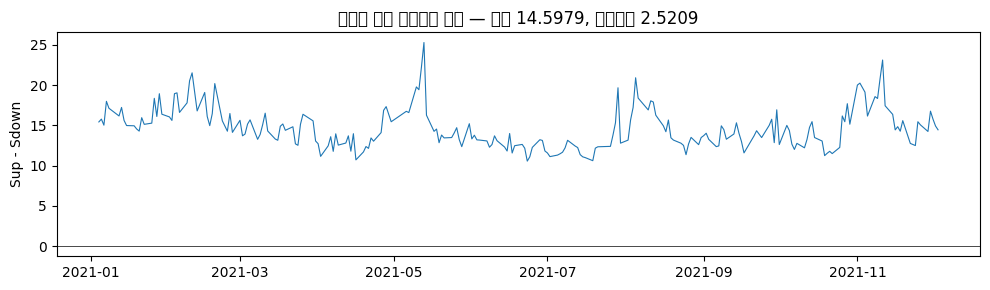

In [10]:
# 일별 스프레드 수익을 시계열로 시각화.
daily = sub.groupby("Date").apply(jpx_metric.daily_spread_return, include_groups=False)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(daily.index, daily.values, lw=0.8)
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"오라클 일별 스프레드 수익 — 평균 {daily.mean():.4f}, 표준편차 {daily.std():.4f}")
ax.set_ylabel("Sup - Sdown")
fig.tight_layout()
plt.show()

## 6. 보조 파일 훑어보기

`stock_prices` 외에 대회가 제공하는 다른 파일들의 형태를 간단히 확인합니다.

In [11]:
# 6-1. secondary_stock_prices — 유동성 낮은 부수 종목.
sec = jpx_loader.load_secondary_stock_prices("train")
print("secondary shape:", sec.shape, "| 종목수:", sec["SecuritiesCode"].nunique())
sec.head(2)

secondary shape: (2384575, 12) | 종목수: 2371


,RowId,Date,SecuritiesCode,Open,High,Low,Close,Volume,AdjustmentFactor,ExpectedDividend,SupervisionFlag,Target
0,20170104_1305,2017-01-04,1305,1594.0,1618.0,1594.0,1615.0,538190,1.0,NaN,False,-0.001855
1,20170104_1306,2017-01-04,1306,1575.0,1595.0,1573.0,1593.0,2494980,1.0,NaN,False,-0.000627


In [12]:
# 6-2. trades — 주간 거래 요약.
tr = jpx_loader.load_trades("train")
print("trades shape:", tr.shape)
tr.head(2)

trades shape: (1712, 56)


,Date,StartDate,EndDate,Section,TotalSales,TotalPurchases,TotalTotal,TotalBalance,ProprietarySales,ProprietaryPurchases,...,CityBKsRegionalBKsEtcTotal,CityBKsRegionalBKsEtcBalance,TrustBanksSales,TrustBanksPurchases,TrustBanksTotal,TrustBanksBalance,OtherFinancialInstitutionsSales,OtherFinancialInstitutionsPurchases,OtherFinancialInstitutionsTotal,OtherFinancialInstitutionsBalance
0,2017-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# 6-3. financials — 분기 실적.
fin = jpx_loader.load_financials("train")
print("financials shape:", fin.shape)
fin.head(2)

financials shape: (92956, 45)


/home/lacid/projects/toy/src/jpx_loader.py:79: DtypeWarning: Columns (14,15,16,17,18,19,42,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,DisclosureNumber,DateCode,Date,SecuritiesCode,DisclosedDate,DisclosedTime,DisclosedUnixTime,TypeOfDocument,CurrentPeriodEndDate,TypeOfCurrentPeriod,...,ForecastEarningsPerShare,ApplyingOfSpecificAccountingOfTheQuarterlyFinancialStatements,MaterialChangesInSubsidiaries,ChangesBasedOnRevisionsOfAccountingStandard,ChangesOtherThanOnesBasedOnRevisionsOfAccountingStandard,ChangesInAccountingEstimates,RetrospectiveRestatement,NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock,NumberOfTreasuryStockAtTheEndOfFiscalYear,AverageNumberOfShares
0,2.016121e+13,20170104_2753,2017-01-04,2753.0,2017-01-04,07:30:00,1.483483e+09,3QFinancialStatements_Consolidated_JP,2016-12-31,3Q,...,319.76,NaN,False,True,False,False,False,6848800.0,－,6848800.0
1,2.017010e+13,20170104_3353,2017-01-04,3353.0,2017-01-04,15:00:00,1.483510e+09,3QFinancialStatements_Consolidated_JP,2016-11-30,3Q,...,485.36,NaN,False,True,False,False,False,2035000.0,118917,1916083.0


In [14]:
# 6-4. options — 옵션 시세.
opt = jpx_loader.load_options("train")
print("options shape:", opt.shape)
opt.head(2)

/home/lacid/projects/toy/src/jpx_loader.py:79: DtypeWarning: Columns (7,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


options shape: (3567694, 31)


,DateCode,Date,OptionsCode,WholeDayOpen,WholeDayHigh,WholeDayLow,WholeDayClose,NightSessionOpen,NightSessionHigh,NightSessionLow,...,Putcall,LastTradingDay,SpecialQuotationDay,SettlementPrice,TheoreticalPrice,BaseVolatility,ImpliedVolatility,InterestRate,DividendRate,Dividend
0,20170104_132010018,2017-01-04,132010018,650.0,650.0,480.0,480.0,0.0000,0.0000,0.0000,...,1,20170112,20170113,480.0,478.4587,17.4736,17.5865,0.0091,0.0,0.0
1,20170104_132010118,2017-01-04,132010118,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,1,20170112,20170113,575.0,571.1385,17.4736,16.5000,0.0091,0.0,0.0


In [15]:
# 6-5. stock_list — 메타정보 (회사명, 섹터 등).
slist = jpx_loader.load_stock_list()
print("stock_list shape:", slist.shape)
print("섹터별 종목 수 (상위 10):")
print(slist["17SectorName"].value_counts().head(10))

stock_list shape: (4417, 16)
섹터별 종목 수 (상위 10):
17SectorName
IT & SERVICES, OTHERS                           1155
-                                                500
RETAIL TRADE                                     339
COMMERCIAL & WHOLESALE TRADE                     311
CONSTRUCTION & MATERIALS                         303
ELECTRIC APPLIANCES & PRECISION INSTRUMENTS      293
RAW MATERIALS & CHEMICALS                        288
MACHINERY                                        228
REAL ESTATE                                      137
FOODS                                            136
Name: count, dtype: int64


## 결론

- 대회 데이터 구조와 공식 메트릭(`calc_spread_return_sharpe`)을 `src/jpx_*.py`로 모듈화해 재사용성을 높였다.
- 오라클 Sharpe(≈5~7)는 **미래 Target을 본 상한값**으로, 실제 모델은 이 훨씬 아래를 목표로 한다.
- 다음 단계: 피처 엔지니어링 → 베이스라인(XGBoost on lag features) → 딥러닝 모델.
- 이상치/레짐 전환은 `04_jpx_change_point.ipynb`에서 다룬다.